(2, 1024, 1024)
(1024, 1024)


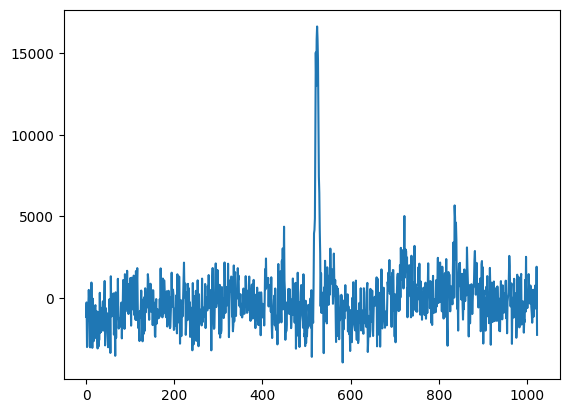


Vertical Fit Results:
Sigma: 0.25, FWHM: 0.60

Calibration results:
(0.275, 0.00481, 1.0, 1.0, 1.7, 0.87, 0.0, 0.0)


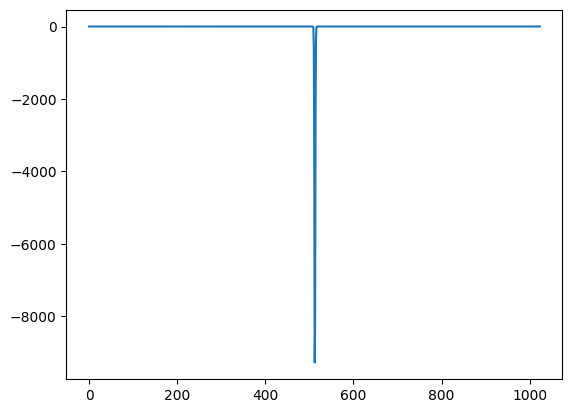

In [1]:
# Import necessary modules
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, date, EPWgrating, EPWcw, IAWcw, IAWgrating, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            #data = data[frame_idx, :, :]
            print(data.shape)
            data = data.astype(float)
            data = np.squeeze(data[0,:,:] - data[1,:,:])
        print(data.shape)
        #separate analysis by type 
        if tstype == "temporal":
            
            # Find maximum coordinates
            ver_lineout = np.sum(data, axis = 1)
            plt.plot(ver_lineout)
            plt.show()
            
            # Gaussian fitting for vertical lineout
            x_ver = np.arange(ver_lineout.size)        
            ver_initial_guess = (
                np.max(ver_lineout),
                512, # Initial guess for peak position
                1.0,
                np.min(ver_lineout)
            )
            ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
            ver_A, mu_ver, sigma_ver, offset_ver = ver_params
            
            fit_A = ver_params[0]
            fit_B = ver_params[1]
    
            fit_y = gaussian(x_ver, fit_A,fit_B,1,1)
            plt.plot(x_ver, fit_y)
            fwhm_ver = 2.3548 * sigma_ver
            mu_hor = sigma_hor = 0
            print(f"\nVertical Fit Results:")
            print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
            

        else:
            #same analysis as above but now for ccd
            hor_lineout = np.sum(data, axis = 0)
            plt.plot(hor_lineout)
            plt.show()
    
            # Gaussian fitting for horizontal lineout
            x_hor = np.arange(hor_lineout.size)
            hor_initial_guess = (
                np.max(hor_lineout),
                512, 
                1.0,
                np.min(hor_lineout)
            )
            hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
            hor_A, mu_hor, sigma_hor, offset_hor = hor_params
            plt.plot(hor_params)
            plt.show()
            fwhm_hor = 2.3548 * sigma_hor            
            mu_ver = sigma_ver = 0

            print(f"\nHorizontal Fit Results:")
            print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")
            

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1

        return calibrations_table(
            EPWgrating, EPWcw, IAWcw, IAWgrating, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, EPWcw, IAWcw, IAWgrating, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

  
    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " temporal" :
        # calibration data grating cw and corresponding disperssions 
        #IAW ROSS
        iaw_cali = {
            (1800, 365): 0.00984,
            (1800, 366): 0.00986,
            (1800, 520): 0.00902,
            (1800, 524): 0.00902,
            (2160, 522): 0.00686,
            (2160, 525): 0.00683,
            (2400, 351): 0.00711,
            (2400, 520): 0.00575,
            (2400, 522): 0.00571,
            (3600, 264): 0.00446,
            (3600, 265): 0.00449,
            (3600, 351): 0.00378  }
        #EPW ROSS
        epw_cali = {
            (150, 263) : 0.4156,
            (150, 351) : 0.4153,
            (150, 527) : 0.4153,
            (600, 320) : 0.1019,
            (1200, 190) : 0.05069,
            (1200, 180) : 0.05026    }
        try:
            EPWROSSDisp = epw_cali[(EPWgrating, EPWcw)]
            IAWDisp = iaw_cali[(IAWgrating, IAWcw)]
        except KeyError as e:
            raise ValueError(f"Invalid calibration parameters: {e}")
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp
            

    else: # tstype is imaging
        #EPW CCD
        epw_cali = {
            (150, 260) : 0.274,
            (150, 351) : 0.275,
            (150, 527) : 0.277,
            (600, 320) : 0.0678,
            (600, 685) : 0.0669,
            (1200, 180) : 0.0331  }
    
        
        # IAW CCD calib): ration data
        iaw_cali = {
            (1800, 701): 0.00482,
            (1800, 707): 0.00481,
            (2160, 522): 0.00437,
            (2160, 525): 0.00448,
            (2400, 351): 0.00446,
            (2400, 520): 0.00368,
            (2400, 522): 0.00365,
            (3600, 264): 0.00286,
            (3600, 265): 0.00284

        }
        try:
            EPWDisp = epw_cali[(EPWgrating, EPWcw)]
            IAWDisp = iaw_cali[(IAWgrating, IAWcw)]
        except KeyError as e:
            raise ValueError(f"Invalid calibration parameters: {e}")
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp


    return  EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="2w_532alignment_527cw_epwROSS_200ph.hdf",
            date = 2025,
            EPWgrating=150,
            EPWcw = 351,
            IAWcw=707,
            IAWgrating=1800,
            telescope="refractive",
            tstype="temporal"
        )
        print("\nCalibration results:")
        print(results)
        #print(f"Calibrated EPW y-axis: {results[0][:5]}...")
       # print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

In [2]:
import pandas as pd
from datetime import datetime

#Save results on excel file 
def categorize_file(filename):
    lower_name = filename.lower()
    if 'iaw' in lower_name:
        if 'ccd' in lower_name:
            return 'iaw_ccd'
        elif 'ross' in lower_name:
            return 'iaw_ross'
    elif 'epw' in lower_name:
        if 'ccd' in lower_name:
            return 'epw_ccd'
        elif 'ross' in lower_name:
            return 'epw_ross'
    return 'other'

def save_to_excel(results, filename=None):
    """
    Save calibration results to Excel file with timestamp
    Returns: Output filename
    """
    # Unpack results
    #axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW = results
    EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW = results

    date = 2025
    
    category_data = {
        'iaw_ccd': [], 'iaw_ross': [],
        'epw_ccd': [], 'epw_ross': []
    }
    category = categorize_filename(filename)
    if 'epw' in category:
        stats = {
            'dispersion':EPWDisp,
            'off-set' : EPWoff,
            'stdv' : stdev_EPW,
            'magnification' : magE
        }
    elif 'iaw' in category:
        stats = {
            'dispersion':IAWDisp,
            'off-set' : IAWoff,
            'stdv' : stdev_IAW,
            'magnification' : magI
        }
        
    category_data[category].append(stats)
    all_data = []
    
    df_stats = pd.DataFrame(all_data)
    categories = ['iaw ccd', 'epw ccd', 'iaw ross', 'epw ross']
    column_order = ['Year'] + [
        f"{cat} - {metric}" for cat in categories 
        for metric in ['dispersion', 'off-set', 'stdv', 'magnification']
    ]
    df_stats = df_stats.reindex(columns=column_order)
    
    # Create Excel writer
    with pd.ExcelWriter(
        'calibrations_table.xlsx',
        engine='xlsxwriter',
        engine_kwargs={'options': {'nan_inf_to_errors': True}}
    ) as writer:
        # Write statistics data starting at row 3 (Excel row 4)
        df_stats.to_excel(writer, sheet_name='Calibrations', index=False, startrow=3)
        
        workbook = writer.book
        stats_sheet = writer.sheets['Calibrations']
        
        # Create header format
        header_format = workbook.add_format({
            'bold': True,
            'align': 'center',
            'valign': 'vcenter',
            'border': 1
        })
        
        # Write and merge headers
        # Year header (Excel rows 1-2)
        stats_sheet.merge_range('A1:A2', 'Year', header_format)
        
        # Category headers (Excel row 1)
        col_idx = 1
        for category in categories:
            stats_sheet.merge_range(0, col_idx, 0, col_idx+3, category, header_format)
            col_idx += 4
        
        # Metric subheaders (Excel row 2)
        col_idx = 1
        for _ in categories:
            for metric in ['dispersion', 'off-set', 'stdv', 'magnification']:
                stats_sheet.write(1, col_idx, metric, header_format)
                col_idx += 1
        
        # Format data cells
        num_format = workbook.add_format({'num_format': '0.000'})
        total_format = workbook.add_format({'num_format': '#,##0'})
        
        for df_row in range(len(df_stats)):
            excel_row = df_row + 3  # Data starts at Excel row 4
            # Year column
            stats_sheet.write(excel_row, 0, df_stats.iloc[df_row, 0])
            
            # Data columns
            for col in range(1, len(df_stats.columns)):
                value = df_stats.iloc[df_row, col]
                if pd.isna(value):
                    stats_sheet.write_blank(excel_row, col, None)
                elif (col % 4) == 0:  # Total columns
                    stats_sheet.write(excel_row, col, value, total_format)
                else:
                    stats_sheet.write(excel_row, col, value, num_format)
        
        # Set column widths
        stats_sheet.set_column(0, 0, 10)  # Year column
        for col in range(1, len(df_stats.columns)):
            stats_sheet.set_column(col, col, 15)
    

In [ ]:
import pandas as pd
def save_to_excel(results, filename=None):
    """
    Save calibration results to Excel file with timestamp
    Returns: Output filename
    """
    # Unpack results
    #axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW = results
    EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW = results

    def process_year(year):
    
        year_dir = os.path.join(base_dir, str(year))
        if not os.path.exists(year_dir):
            return None, []
        
    hdf_files = sorted([f for f in os.listdir(year_dir) if f.endswith('.hdf')])
    year_stats = {'Year': year}
    hist_data = []
    
    category_data = {
        'iaw_ccd': [], 'iaw_ross': [],
        'epw_ccd': [], 'epw_ross': []
    }
    
    for file_name in hdf_files:
        file_path = os.path.join(year_dir, file_name)
        filename = os.path.basename(file_path)
        category = categorize_file(filename)
        
        if category not in category_data:
            continue
            
        stats, hist = analyze_file(file_path, year, category)
        if stats and hist:
            category_data[category].append(stats)
            hist_data.append({
                'Year': year,
                'Filename': filename,
                'Category': category.replace('_', ' '),
                'Histogram': hist
            })
    
    # Aggregate statistics
    for cat, entries in category_data.items():
        prefix = cat.replace('_', ' ')
        if entries:
            year_stats[f"{prefix} - mean"] = np.mean([e['mean'] for e in entries])
            year_stats[f"{prefix} - median"] = np.mean([e['median'] for e in entries])
            year_stats[f"{prefix} - stdv"] = np.mean([e['stdv'] for e in entries])
            year_stats[f"{prefix} - total"] = np.sum([e['total'] for e in entries])
        else:
            year_stats[f"{prefix} - mean"] = np.nan
            year_stats[f"{prefix} - median"] = np.nan
            year_stats[f"{prefix} - stdv"] = np.nan
            year_stats[f"{prefix} - total"] = 0
    
    return year_stats, hist_data

# Main processing
all_data = []
all_hists = []

for year in range(2015, 2026):
    print(f"Processing {year}")
    year_stat, year_hists = process_year(year)
    if year_stat:
        all_data.append(year_stat)
    if year_hists:
        all_hists.extend(year_hists)

# Create and save Excel report
if all_data:
    # Statistics sheet
    df_stats = pd.DataFrame(all_data)
    categories = ['iaw ccd', 'iaw ross', 'epw ccd', 'epw ross']
    column_order = ['Year'] + [
        f"{cat} - {metric}" for cat in categories 
        for metric in ['mean', 'median', 'stdv', 'total']
    ]
    df_stats = df_stats.reindex(columns=column_order)
    
    # Histograms sheet
    df_hists = pd.DataFrame(all_hists)
    
    # Save to Excel
    with pd.ExcelWriter(
        'analysis_results.xlsx',
        engine='xlsxwriter',
        engine_kwargs={'options': {'nan_inf_to_errors': True}}
    ) as writer:
        # Statistics sheet
        df_stats.to_excel(writer, sheet_name='Statistics', index=False, startrow=2)
        
        # Format statistics sheet
        workbook = writer.book
        stats_sheet = writer.sheets['Statistics']
        
        # Merge headers
        header_format = workbook.add_format({
            'bold': True, 'align': 'center', 'valign': 'vcenter', 'border': 1
        })
        stats_sheet.merge_range('A1:A2', 'Year', header_format)
        col_idx = 1
        for category in categories:
            stats_sheet.merge_range(0, col_idx, 0, col_idx+3, category, header_format)
            for i, metric in enumerate(['mean', 'median', 'stdv', 'total']):
                stats_sheet.write(1, col_idx+i, metric, header_format)
            col_idx += 4
        
        # Histograms sheet
        df_hists.to_excel(writer, sheet_name='Histograms', index=False)
        hist_sheet = writer.sheets['Histograms']
        
        # Insert images
        for idx, row in df_hists.iterrows():
            img_data = BytesIO(row['Histogram'])
            hist_sheet.insert_image(
                idx + 1, 3,  # Start from row 1, column D
                row['Filename'],
                {'image_data': img_data, 'x_offset': 5, 'y_offset': 5}
            )
        
        # Set column widths and row heights
        hist_sheet.set_column('A:A', 10)   # Year
        hist_sheet.set_column('B:B', 30)   # Filename
        hist_sheet.set_column('C:C', 15)   # Category
        hist_sheet.set_column('D:D', 60)   # Histogram
        
        for row in range(1, len(df_hists)+1):
            hist_sheet.set_row(row, 100)

        # Format numbers in statistics sheet
        num_format = workbook.add_format({'num_format': '0.000'})
        total_format = workbook.add_format({'num_format': '#,##0'})
        for row in range(2, len(df_stats)+2):
            for col in range(1, len(df_stats.columns)):
                value = df_stats.iloc[row-2, col]
                if pd.isna(value):
                    stats_sheet.write_blank(row, col, None)
                elif (col % 4) == 0:  # Total columns
                    stats_sheet.write(row, col, value, total_format)
                else:
                    stats_sheet.write(row, col, value, num_format)
        
        stats_sheet.set_column(0, 0, 10)  # Year column
        for col in range(1, len(df_stats.columns)):
            stats_sheet.set_column(col, col, 15)

    print("Analysis results saved to analysis_results.xlsx")
else:
    print("No data processed")

IndentationError: expected an indented block after function definition on line 11 (634901251.py, line 12)

: 